### Spherical pendulum: numerical solution

The Lagrangian for a spherical pendulum in spherical coordinates is:

$$
    \boxed{L = \frac{1}{2} m l ^ 2 \left( \dot\theta^2 + \sin^2\theta\,\dot\varphi^2 \right) + mgl \cos\theta}
$$

Applying the Euler-Lagrange equations, we obtain:

$$
    \boxed{\begin{cases}
        \ddot{\theta} = \sin\theta\cos\theta \, \dot{\varphi}^{2} - \frac{g}{l}\sin\theta \\
        \ddot{\varphi} = -2\cot\theta \, \dot{\theta}\dot{\varphi}
    \end{cases}}
$$

The first equation yields the conservation law of mechanical energy, whereas the second equation yields the conservation law of angular momentum $L_z$:

$$
   \boxed{ L_z = m l ^ 2 \sin ^ 2(\theta) \dot{\phi}}
$$

Therefore we can write a single differential equation for $\theta (t)$:

$$
    \boxed{\ddot\theta = \frac{L_z^2 \cos\theta}{m^2 l^4 \sin^3\theta} - \frac{g}{l}\sin\theta}
$$

We want to solve it numerically accounting to the following conditions:

$$
    \boxed{\begin{cases}
        \theta(0) = \theta_0 \\
        \dot{\theta}(0) = 0 \\
        \phi(0) = 0 \\
        \dot{\phi}(0) = \dot{\phi_0} \\
    \end{cases}}
$$

So, $L_z = m l ^ 2 \sin ^ 2(\theta_0) \dot{\phi_0}$

To make the equation dimensionless we introduce a dimensionless time variable $\tau$ and a dimensionless parameter $\alpha$. Let:

$$
    \boxed{\tau = t \sqrt{\frac{g}{l}}}
$$

The original equation becomes:

$$
    \frac{g}{l}\, \ddot{\theta} = \frac{L_z^2 \cos\theta}{m^2 l^4 \sin^3\theta} - \frac{g}{l}\sin\theta
$$  

Multiply through by $l/g$:  

$$
    \ddot{\theta} = \frac{L_z^2 \cos\theta}{m^2 l^3 g \sin^3\theta} - \sin\theta
$$

Now define the dimensionless constant:  

$$
    \alpha = \frac{L_z^2}{m^2 l^3 g}
$$  

Since $L_z = m l^2 \sin^2\theta_0\,\dot{\phi}_0$, this simplifies to:  

$$
    \boxed{\alpha = \frac{l}{g}\,\dot{\phi}_0^2 \sin^4\theta_0}
$$

Thus the fully dimensionless differential equation is:  

$$
    \boxed{\ddot{\theta} = \alpha\,\frac{\cos\theta}{\sin^3\theta} - \sin\theta}
$$

Let's solve it.

In [1]:
# Libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid

In [2]:
# Parameters (dimensionless)
alpha = 2.5
theta_0 = np.pi / 3.0
d_theta_0 = 0.0

In [3]:
# Time span (dimensionless tau)
tau_max = 40.0
tau = np.linspace(0, tau_max, 1_000)  # points for output

In [4]:
# Differential equation for theta
def eq(tau, y):
    theta, d_theta = y
    dd_theta = alpha * np.cos(theta) / (np.sin(theta) ** 3) - np.sin(theta)
    return [d_theta, dd_theta]

In [5]:
# Solve for theta(tau)
sol = solve_ivp(fun = eq,
                t_span = (0, tau_max),
                y0 = [theta_0, d_theta_0],
                t_eval = tau,
                method = 'RK45')
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.004e-02 ...  3.996e+01  4.000e+01]
        y: [[ 1.047e+00  1.048e+00 ...  1.117e+00  1.103e+00]
            [ 0.000e+00  4.230e-02 ... -3.604e-01 -3.343e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 626
     njev: 0
      nlu: 0

In [6]:
# theta(tau)
theta = sol.y[0]
theta

array([1.04719755, 1.04804521, 1.0505785 , 1.05476856, 1.06056688,
       1.06790845, 1.07671566, 1.08689857, 1.09835492, 1.11097009,
       1.12461716, 1.1391692 , 1.15450116, 1.17048345, 1.18698867,
       1.2038916 , 1.22106925, 1.23840082, 1.25576768, 1.27305345,
       1.2901457 , 1.30695111, 1.32337355, 1.33931951, 1.35470138,
       1.36943752, 1.38345222, 1.3966757 , 1.4090441 , 1.42049952,
       1.43098999, 1.44046951, 1.44890435, 1.45625768, 1.46249063,
       1.46757068, 1.47147167, 1.47417378, 1.47566354, 1.47593383,
       1.47498388, 1.47281926, 1.46945189, 1.46490004, 1.45918833,
       1.45234772, 1.44441277, 1.43541357, 1.42538528, 1.41436949,
       1.40241413, 1.38957349, 1.37590819, 1.36148523, 1.34637793,
       1.330666  , 1.31443547, 1.29777872, 1.28079449, 1.26358789,
       1.24624836, 1.22886917, 1.21158216, 1.19451753, 1.1778035 ,
       1.16156634, 1.14593031, 1.13101771, 1.11694886, 1.10384212,
       1.09181386, 1.08097846, 1.07144836, 1.06333398, 1.05672

To compute $\phi(\tau)$, integrate:

$$
    \phi(\tau) = \phi_0 + \sqrt{\alpha} \int_{0}^{\tau} \frac{d\tau'}{\sin^2\theta(\tau')}
$$

In [7]:
# Compute phi(tau) from conservation law of angular momentum
integrand = 1 / (np.sin(theta) ** 2)

# Initial value of phi(tau)
phi_0 = 0.0

# Cumulative integration
phi = np.sqrt(alpha) * cumulative_trapezoid(integrand, tau, initial = 0)
phi += phi_0 # considering phi_0, eventually
phi

array([ 0.        ,  0.08437057,  0.16857732,  0.25246115,  0.33587209,
        0.41867322,  0.50074361,  0.58198039,  0.6623001 ,  0.74163934,
        0.81995478,  0.89722213,  0.97343427,  1.04859931,  1.12273869,
        1.19588492,  1.26807955,  1.33937121,  1.40981384,  1.47946513,
        1.54838503,  1.61663421,  1.68427287,  1.75136005,  1.81795291,
        1.88410616,  1.94987149,  2.01529731,  2.08042847,  2.14530615,
        2.20996783,  2.27444735,  2.33877502,  2.40297783,  2.46707986,
        2.53110266,  2.59506558,  2.65898616,  2.72288062,  2.78676427,
        2.85065208,  2.91455914,  2.97850118,  3.04249503,  3.10655914,
        3.1707139 ,  3.2349821 ,  3.29938935,  3.36396441,  3.42873952,
        3.49375048,  3.55903684,  3.62464187,  3.69061248,  3.75699902,
        3.82385502,  3.8912367 ,  3.95920246,  4.02781208,  4.09712579,
        4.16720376,  4.2381054 ,  4.30988734,  4.38260111,  4.45629154,
        4.53099497,  4.60673754,  4.68353325,  4.76138218,  4.84

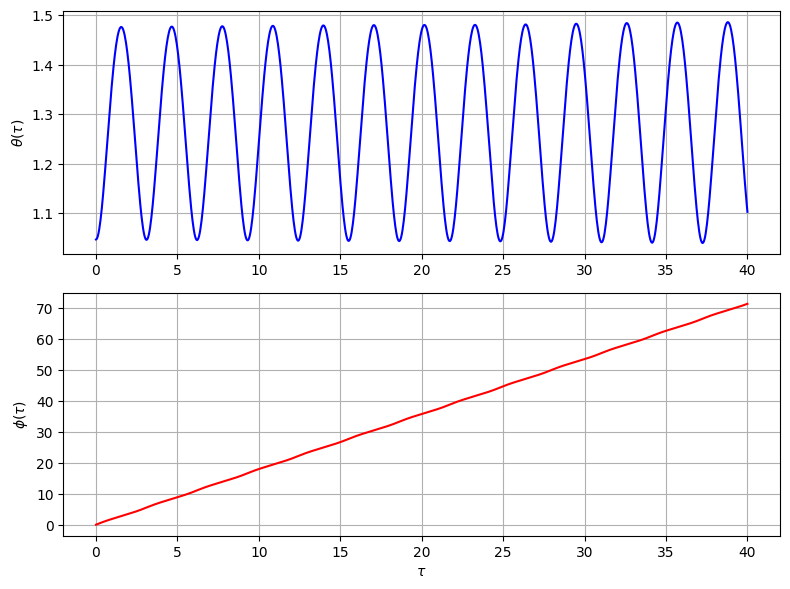

In [8]:
# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (8, 6))

ax1.plot(tau, theta, 'b-')
ax1.set_ylabel(r'$\theta(\tau)$')
ax1.grid(True)

ax2.plot(tau, phi, 'r-')
ax2.set_xlabel(r'$\tau$')
ax2.set_ylabel(r'$\phi(\tau)$')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Libraries for animation
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

In [10]:
# Cartesian coordinates (dimensionless: x, y, z / l)
x_l = np.sin(theta) * np.cos(phi)
y_l = np.sin(theta) * np.sin(phi)
z_l = -np.cos(theta) # hanging downward

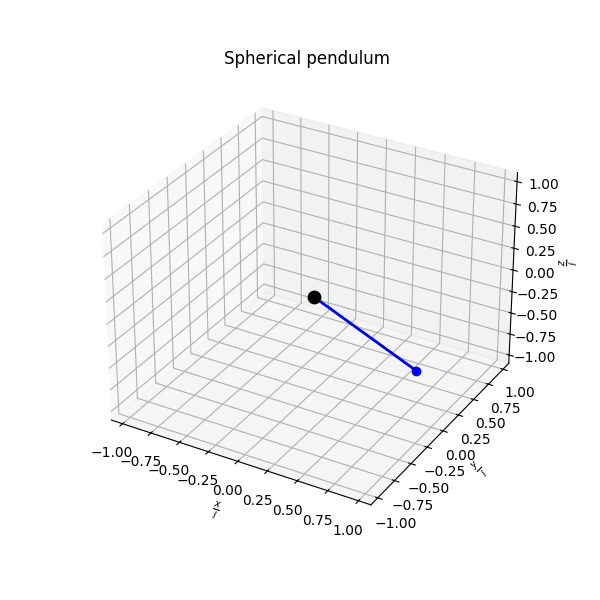

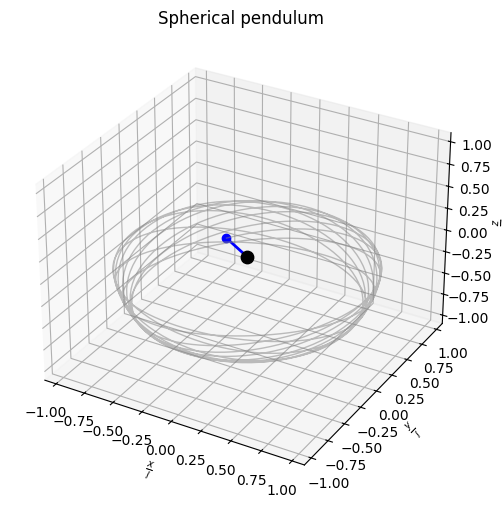

In [11]:
# Set up the 3D figure and axes. Making an animation
fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
ax.set_xlabel(r'$\frac{x}{l}$')
ax.set_ylabel(r'$\frac{y}{l}$')
ax.set_zlabel(r'$\frac{z}{l}$')
ax.set_title('Spherical pendulum')

ax.scatter([0], [0], [0], c = 'black', s = 80, marker = 'o', label = 'pivot')
line, = ax.plot([], [], [], 'o-', lw = 2, color = 'blue', markersize = 6, label = 'bob')
trail, = ax.plot([], [], [], 'gray', alpha = 0.5, lw = 1)

def init():
    line.set_data([], [])
    line.set_3d_properties([])
    trail.set_data([], [])
    trail.set_3d_properties([])
    return (line, trail)

def update(frame):
    current_x = x_l[frame]
    current_y = y_l[frame]
    current_z = z_l[frame]

    line.set_data([0, current_x], [0, current_y])
    line.set_3d_properties([0, current_z])
    trail.set_data(x_l[:frame + 1], y_l[:frame + 1])
    trail.set_3d_properties(z_l[:frame + 1])

    return (line, trail)

frames = range(0, len(tau), 1)

anim = FuncAnimation(fig, update, frames = frames, init_func = init, interval = 50, blit = True, repeat = True)
anim.save('pendulum.gif', writer = PillowWriter(fps = 30))

Image(filename = 'pendulum.gif') # Display the GIF in the notebook